In [1]:
import sys
import brian2

print(sys.executable)
print("Brian2:", brian2.__version__)

/opt/anaconda3/envs/brian2-env/bin/python
Brian2: 2.10.1


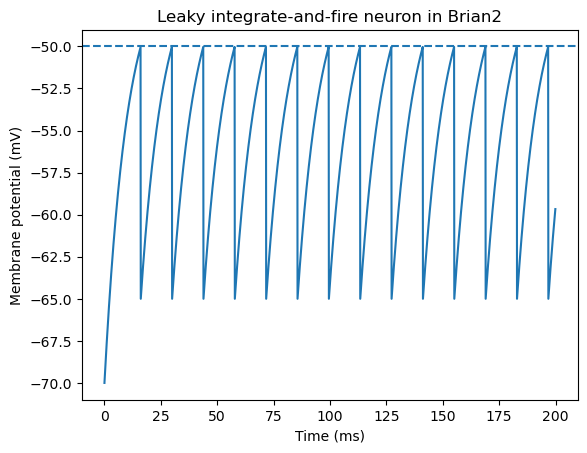

Number of spikes: 14
Spike times: [ 16.   29.9  43.8  57.7  71.6  85.5  99.4 113.3 127.2 141.1 155.  168.9
 182.8 196.7]


In [2]:
%matplotlib inline

from brian2 import *
import matplotlib.pyplot as plt

start_scope()

tau = 10*ms
v_rest = -70*mV
v_reset = -65*mV
v_threshold = -50*mV
R = 100*Mohm
I = 0.25*nA

eqs = '''
dv/dt = (v_rest - v + R*I)/tau : volt
'''

G = NeuronGroup(
    1,
    eqs,
    threshold='v > v_threshold',
    reset='v = v_reset',
    method='exact'
)

G.v = v_rest

M = StateMonitor(G, 'v', record=True)
S = SpikeMonitor(G)

run(200*ms)

plt.figure()
plt.plot(M.t/ms, M.v[0]/mV)
plt.axhline(v_threshold/mV, linestyle='--')
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.title("Leaky integrate-and-fire neuron in Brian2")
plt.show()

print("Number of spikes:", S.count[0])
print("Spike times:", S.t/ms)